In [1]:
import pandas as pd
d=pd.read_csv("fitness_tracker_dataset.csv")
d

,user_id,date,steps,calories_burned,distance_km,active_minutes,sleep_hours,heart_rate_avg,workout_type,weather_conditions,location,mood
0,468,2023-01-01,4530,2543.02,16.10,613,1.5,176,Walking,Clear,Park,Tired
1,879,2023-01-01,11613,1720.76,8.10,352,6.3,128,Cycling,Fog,Park,Happy
2,152,2023-01-01,27335,1706.35,3.57,236,6.7,134,Yoga,Snow,Park,Neutral
3,311,2023-01-01,13459,2912.38,6.41,1329,11.6,116,Swimming,Rain,Office,Tired
4,759,2023-01-01,15378,3344.51,17.88,52,7.4,84,Swimming,Rain,Office,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,294,2025-09-26,21883,1711.42,4.62,124,7.9,174,Running,Fog,Other,Tired
999996,114,2025-09-26,15451,3961.63,1.93,1316,7.4,161,Cycling,Clear,Park,Tired
999997,85,2025-09-26,17912,3604.77,5.81,187,7.1,74,Swimming,Fog,Gym,Neutral
999998,109,2025-09-26,10072,2724.34,7.42,1203,6.0,74,Swimming,Snow,Gym,Tired


In [2]:
#identify null values
d.columns[d.isna().any()]

Index(['workout_type'], dtype='object')

In [39]:
import numpy as np
d.info()
d1=d.select_dtypes(["int64","float64"])
d=d.head(1000)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             10000 non-null  int64  
 1   date                10000 non-null  object 
 2   steps               10000 non-null  int64  
 3   calories_burned     10000 non-null  float64
 4   distance_km         10000 non-null  float64
 5   active_minutes      10000 non-null  int64  
 6   sleep_hours         10000 non-null  float64
 7   heart_rate_avg      10000 non-null  int64  
 8   workout_type        8605 non-null   object 
 9   weather_conditions  10000 non-null  object 
 10  location            10000 non-null  object 
 11  mood                10000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 937.6+ KB


In [40]:
d1.kurt()

user_id           -1.197421
steps             -1.192054
calories_burned   -1.204385
distance_km       -1.213272
active_minutes    -1.193911
sleep_hours       -1.219273
heart_rate_avg    -1.209518
dtype: float64

In [41]:
x=d[["steps"]]
y=d["calories_burned"]

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.6,random_state=42)

In [44]:
x_train


,steps
24,9712
467,17064
539,20738
531,21470
618,5216
...,...
106,15022
270,8838
860,11418
435,20566


In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
lr=LinearRegression()

In [47]:
#training
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
#testing
y1=lr.predict(x_test)
y1

array([2764.52096613, 2764.54616682, 2764.50236438, 2764.87494496,
       2764.94363633, 2764.24394035, 2764.77393434, 2764.96847331,
       2764.83750764, 2764.22684545, 2764.79804387, 2764.96229004,
       2764.93573838, 2764.39433913, 2764.69607199, 2764.43642689,
       2764.44073959, 2764.43206224, 2764.59321678, 2764.31650276,
       2764.77066085, 2764.36407232, 2764.57009449, 2764.67588545,
       2764.75580023, 2764.87372389, 2764.21442696, 2764.89559913,
       2764.21996072, 2764.63527856, 2764.77993574, 2764.32107526,
       2764.23767915, 2764.88432377, 2764.85532998, 2764.30133039,
       2764.23882227, 2764.36848894, 2764.81124176, 2764.22263667,
       2764.93207519, 2764.22783269, 2764.38854557, 2764.75442329,
       2764.85865544, 2764.75364388, 2764.55032364, 2764.49831148,
       2764.84979622, 2764.93420556, 2764.54047718, 2764.34102797,
       2764.53481352, 2764.97803398, 2764.28735309, 2764.79274393,
       2764.80477271, 2764.5071707 , 2764.49919481, 2764.57531

In [49]:
#comparing
from sklearn.metrics import r2_score

In [50]:
r2_score(y_test,y1)

-0.001270673888023266

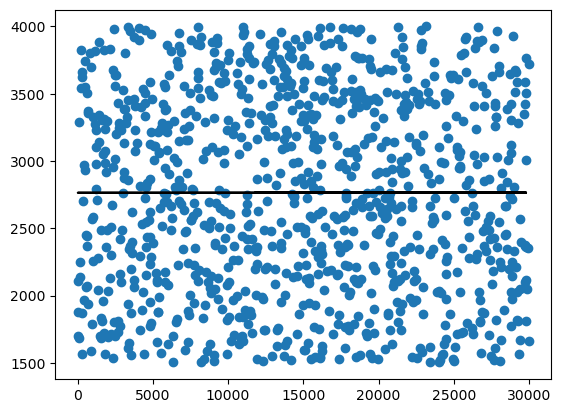

In [51]:
import matplotlib.pyplot as plt
x=d[["steps"]]
y=d["calories_burned"]
plt.scatter(d["steps"],d["calories_burned"])
plt.plot(x_test,y1,color="black")
plt.show()